In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from finta import TA
from scipy.interpolate import CubicSpline

In [2]:
def z_score_normalize(df):
    for col in df.columns:
        df[col] = (df[col] - df[col].mean()) / df[col].std()
    return df

In [26]:
df_harga = pd.read_csv('data/adro/data_harga_teknikal_adro.csv', parse_dates=True)
df_harga.drop(columns=['Date', "Close", "Open", "High", "Low", "Volume", "Change", "Unnamed: 0"], inplace=True)
df_harga

,adx,macd,rsi,%k
0,100.000000,2.600078,62.916610,81.579032
1,67.702296,3.260861,66.234024,94.444410
2,61.331000,2.477208,44.701366,52.777794
3,62.372925,1.341060,39.210225,32.352833
4,62.995799,0.799376,44.136996,20.833485
...,...,...,...,...
2699,15.014763,49.571286,53.066851,45.000000
2700,14.937434,46.610051,52.613183,42.372881
2701,15.001780,41.365664,51.199076,37.288136
2702,14.861962,39.178572,52.571880,42.372881


In [ ]:
ticker = yf.Ticker("bbca.jk")

history = ticker.history(start="2014-01-1", end="2024-12-31", auto_adjust=True)
history

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-01-02 00:00:00+07:00,1624.149743,1649.265461,1615.777837,1640.893555,33065000,0.0,0.0
2014-01-03 00:00:00+07:00,1624.149608,1632.521513,1565.546272,1590.661987,71912500,0.0,0.0
2014-01-06 00:00:00+07:00,1573.918661,1590.662476,1557.174845,1565.546753,58190000,0.0,0.0
2014-01-07 00:00:00+07:00,1565.546104,1582.289912,1561.360151,1569.732056,36152000,0.0,0.0
2014-01-08 00:00:00+07:00,1573.918456,1582.290362,1548.802736,1561.360596,55877500,0.0,0.0
...,...,...,...,...,...,...,...
2024-12-20 00:00:00+07:00,9650.000000,9750.000000,9625.000000,9650.000000,91576900,0.0,0.0
2024-12-23 00:00:00+07:00,9700.000000,9850.000000,9700.000000,9775.000000,43292100,0.0,0.0
2024-12-24 00:00:00+07:00,9850.000000,9900.000000,9750.000000,9750.000000,32415700,0.0,0.0


In [ ]:
test = pd.read_csv('prediction/bbca/price.csv', parse_dates=True, )
test

,true,bilstm,tcn,tcn_bilstm
0,[1.39447044],[1.2845445],[1.3338948],[1.3316536]
1,[1.39447044],[1.3645251],[1.376848],[1.3941694]
2,[1.44174786],[1.3702912],[1.3843628],[1.4063128]
3,[1.40392593],[1.4105836],[1.4239752],[1.4372445]
4,[1.41338103],[1.3788009],[1.408293],[1.427069]
...,...,...,...,...
383,[1.76094527],[1.7553921],[1.8015366],[1.810487]
384,[1.80978517],[1.7322032],[1.7857758],[1.7777303]
385,[1.80001719],[1.7647825],[1.7991598],[1.8175977]
386,[1.81955316],[1.7732024],[1.8108529],[1.8103307]


In [28]:
prediction = {}

def visualize_data(name):
    types = ['price', 'fundamental', 'technical', 'combined']
    for t in types:
        df = pd.read_csv(f'prediction/{name}/{t}.csv')

        # Clean: convert [value] → value
        for col in df.columns:
            df[col] = df[col].apply(lambda x: eval(x)[0] if isinstance(x, str) and x.startswith('[') else x)
        
        # Optional: convert to float
        df = df.astype(float)

        prediction[t] = df

visualize_data('tlkm')

prediction['combined'][57:62]

,true,bilstm,tcn,tcn_bilstm
57,1.024749,1.071067,1.111044,1.031371
58,1.040207,1.066672,1.057253,1.014167
59,1.024749,1.052254,1.047647,0.992348
60,0.993832,1.078408,1.025077,1.010673
61,0.993832,1.015188,1.027918,0.986897


In [22]:
prediction['combined'][152:157]

,true,bilstm,tcn,tcn_bilstm
152,1.218705,1.228145,1.250360,1.233701
153,1.218705,1.222850,1.255413,1.217606
154,1.208314,1.228716,1.241660,1.228226
155,1.239488,1.213967,1.234552,1.212332
156,1.229097,1.225912,1.252910,1.221872


In [4]:
def get_data(stock):
    df = pd.read_csv(f'data/{stock}/data_harga_{stock}.csv', index_col=0, parse_dates=True) 
    return df

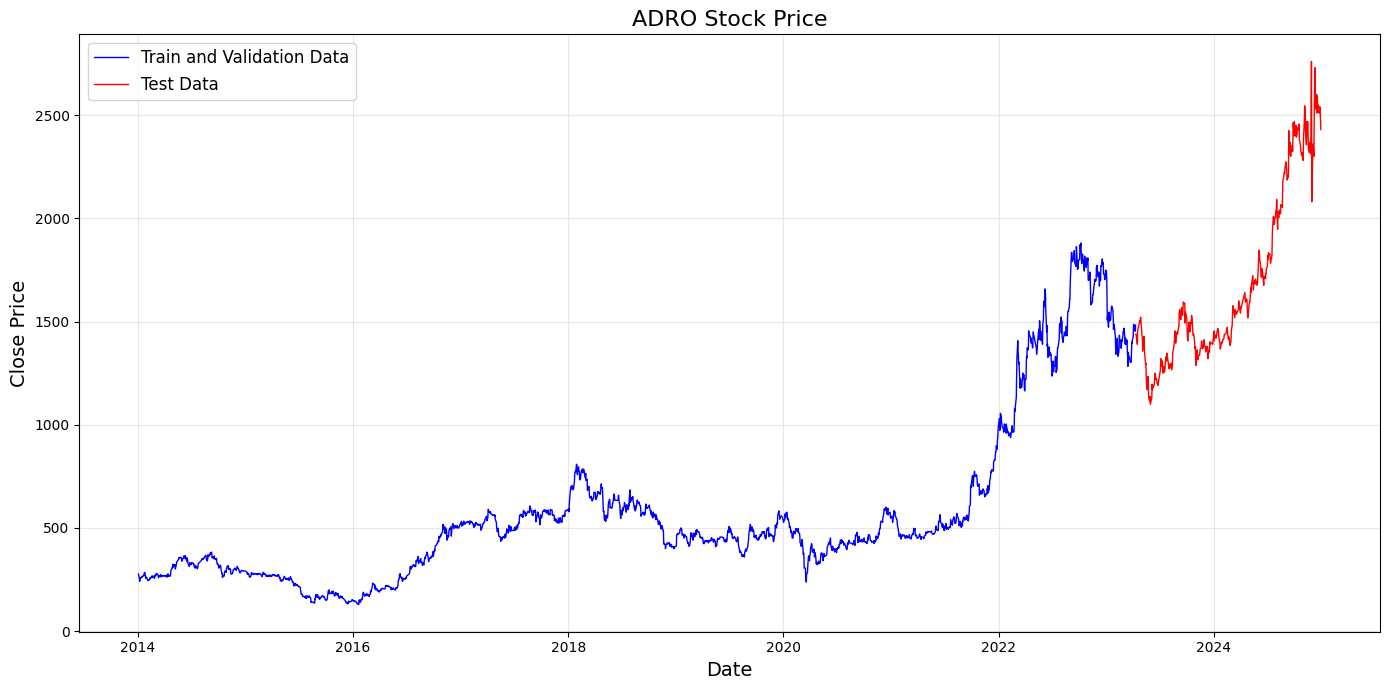

In [11]:
df = get_data("adro")
train = df.iloc[:int(len(df)*0.85)]
test = df.iloc[int(len(df)*0.85):]
plt.figure(figsize=(14, 7))
plt.plot(train.index, train["Close"], label="Train and Validation Data", color="blue", linewidth=1)
plt.plot(test.index, test["Close"], label="Test Data", color="red", linewidth=1)
plt.title("ADRO Stock Price", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Close Price", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

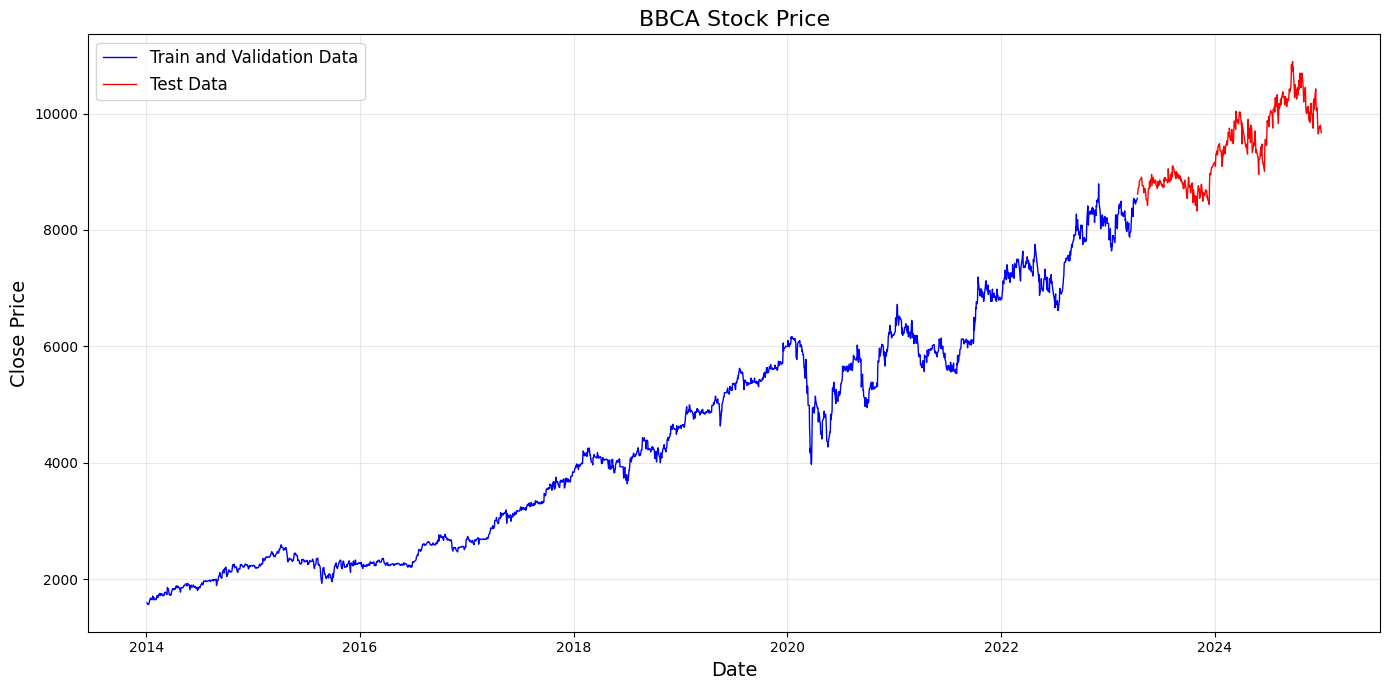

In [12]:
df = get_data("bbca")
train = df.iloc[:int(len(df)*0.85)]
test = df.iloc[int(len(df)*0.85):]
plt.figure(figsize=(14, 7))
plt.plot(train.index, train["Close"], label="Train and Validation Data", color="blue", linewidth=1)
plt.plot(test.index, test["Close"], label="Test Data", color="red", linewidth=1)
plt.title("BBCA Stock Price", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Close Price", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

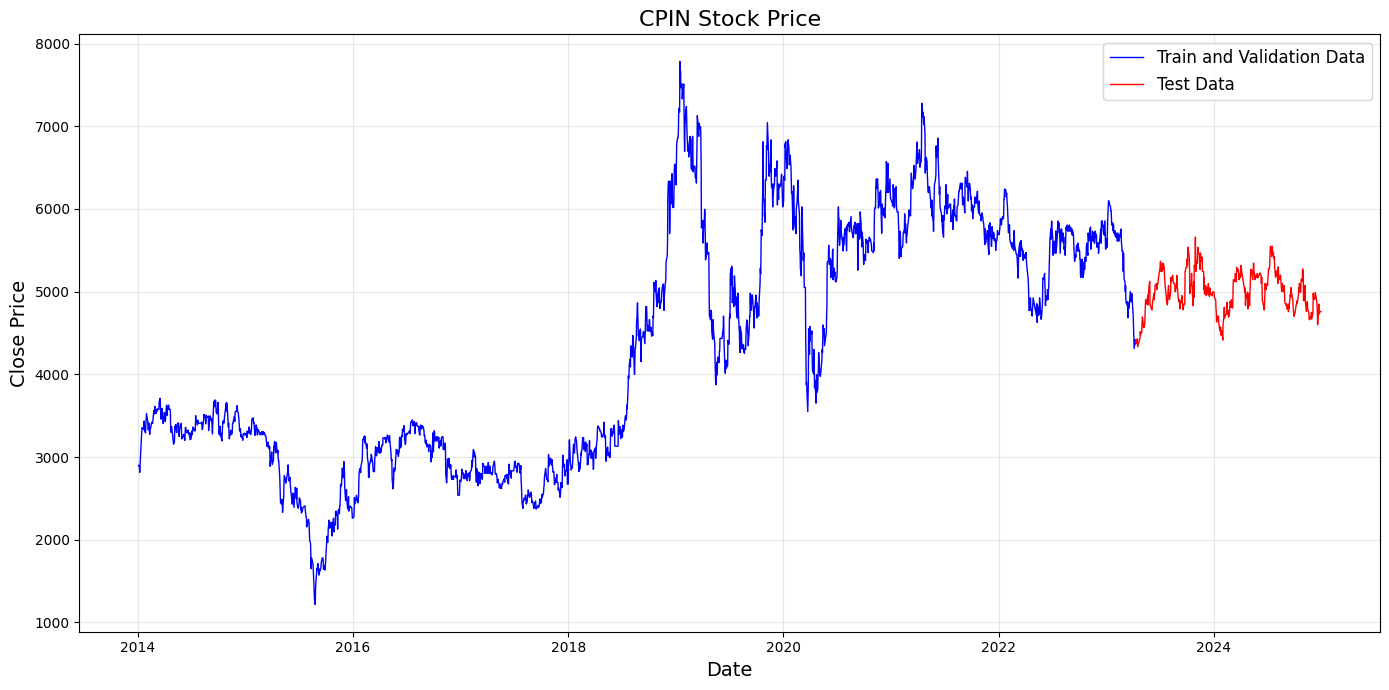

In [13]:
df = get_data("cpin")
train = df.iloc[:int(len(df)*0.85)]
test = df.iloc[int(len(df)*0.85):]
plt.figure(figsize=(14, 7))
plt.plot(train.index, train["Close"], label="Train and Validation Data", color="blue", linewidth=1)
plt.plot(test.index, test["Close"], label="Test Data", color="red", linewidth=1)
plt.title("CPIN Stock Price", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Close Price", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

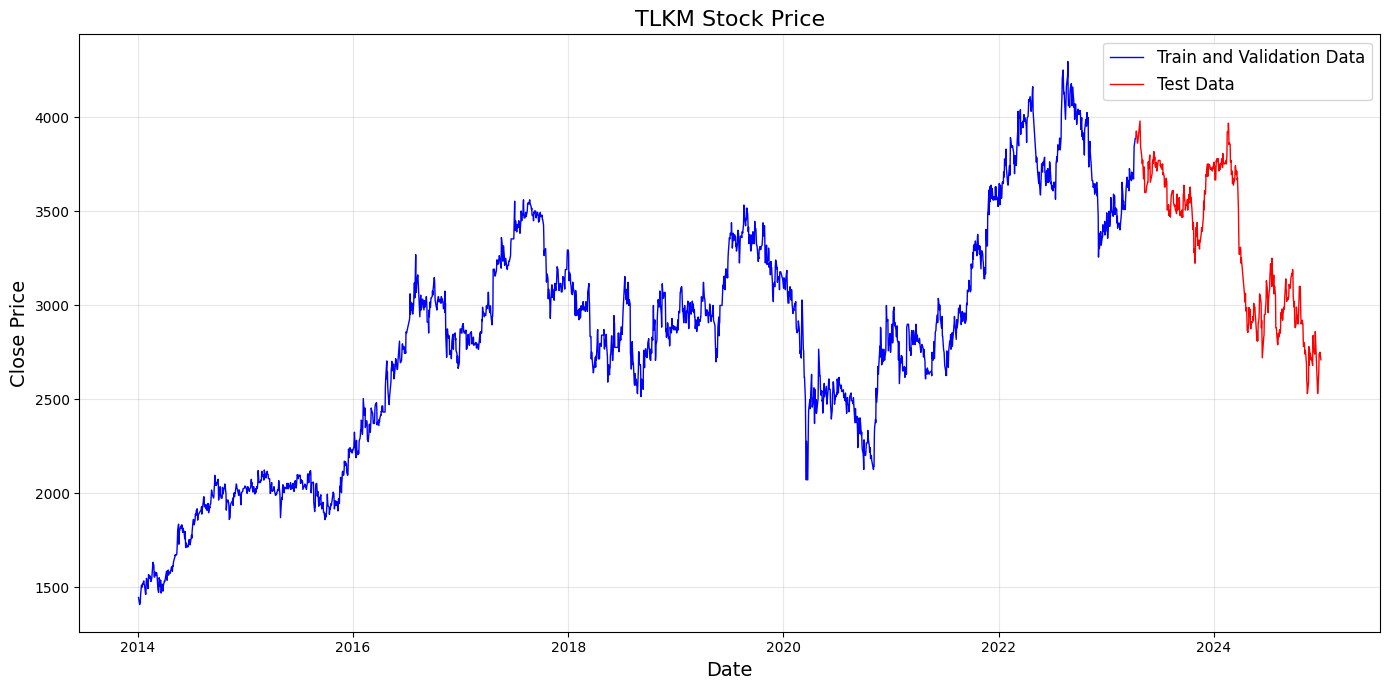

In [14]:
df = get_data("tlkm")
train = df.iloc[:int(len(df)*0.85)]
test = df.iloc[int(len(df)*0.85):]
plt.figure(figsize=(14, 7))
plt.plot(train.index, train["Close"], label="Train and Validation Data", color="blue", linewidth=1)
plt.plot(test.index, test["Close"], label="Test Data", color="red", linewidth=1)
plt.title("TLKM Stock Price", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Close Price", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
def preprocces_data(df):
    df['Change'] = df['Close'].pct_change()
    df.drop(columns=['Dividends', 'Stock Splits'], inplace=True)
    df = df[['Close', 'Open', 'High', 'Low', 'Volume', 'Change']]
    df = df.iloc[1:]
    return df

In [85]:
get_data('tlkm')

                        Date        Close         Open         High  \
0  2014-01-03 00:00:00+07:00  1445.581177  1445.581177  1479.594852   
1  2014-01-06 00:00:00+07:00  1418.370117  1479.594727  1479.594727   
2  2014-01-07 00:00:00+07:00  1408.166138  1418.370240  1418.370240   
3  2014-01-08 00:00:00+07:00  1428.574341  1418.370238  1428.574341   
4  2014-01-09 00:00:00+07:00  1418.370117  1428.574219  1438.778320   

           Low    Volume    Change  
0  1428.574339  60001000 -0.022989  
1  1404.764648  81736300 -0.018824  
2  1401.363403  73637100 -0.007194  
3  1404.764768  84514500  0.014493  
4  1418.370117  71932000 -0.007143  


In [2]:
def get_data(stock):
    ticker = yf.Ticker(f'{stock}.jk')
    df = ticker.history(start="2014-01-1", end="2024-12-31", auto_adjust=True)
    df = preprocces_data(df)
    df.to_csv(f'data/{stock}/data_harga_{stock}.csv')
    df = pd.read_csv(f'data/{stock}/data_harga_{stock}.csv')

In [4]:
df_adro = preprocces_data(df_adro)
df_adro

,Close,Open,High,Low,Volume,Change
Date,,,,,,
2014-01-03 00:00:00+07:00,276.232727,287.172637,289.907615,273.497750,52823000,-0.047170
2014-01-06 00:00:00+07:00,254.352921,276.232742,276.232742,247.515476,95833000,-0.079208
2014-01-07 00:00:00+07:00,240.678009,254.352896,258.455362,237.943032,161316000,-0.053764
2014-01-08 00:00:00+07:00,257.087921,242.045543,257.087921,240.678054,160013700,0.068182
2014-01-09 00:00:00+07:00,258.455353,257.087864,265.292796,255.720376,119583300,0.005319
...,...,...,...,...,...,...
2024-12-20 00:00:00+07:00,2550.000000,2540.000000,2580.000000,2510.000000,65183500,0.003937
2024-12-23 00:00:00+07:00,2540.000000,2580.000000,2590.000000,2520.000000,49626700,-0.003922
2024-12-24 00:00:00+07:00,2510.000000,2540.000000,2610.000000,2510.000000,70990000,-0.011811


In [6]:
df_adro.to_csv('data/adro/data_harga_adro.csv')

In [30]:
df_adro = pd.read_csv('data_harga_adro.csv')
df_adro

,Date,Close,Open,High,Low,Volume,Change
0,2014-01-03 00:00:00+07:00,276.232727,287.172637,289.907615,273.497750,52823000,-0.047170
1,2014-01-06 00:00:00+07:00,254.352936,276.232758,276.232758,247.515491,95833000,-0.079208
2,2014-01-07 00:00:00+07:00,240.677979,254.352864,258.455329,237.943001,161316000,-0.053764
3,2014-01-08 00:00:00+07:00,257.087860,242.045485,257.087860,240.677997,160013700,0.068182
4,2014-01-09 00:00:00+07:00,258.455383,257.087895,265.292827,255.720406,119583300,0.005319
...,...,...,...,...,...,...,...
2693,2024-11-22 00:00:00+07:00,2362.213867,2318.119208,2362.213867,2292.922260,154094300,0.019022
2694,2024-11-25 00:00:00+07:00,2374.812256,2368.513019,2400.009203,2349.615309,192437100,0.005333
2695,2024-11-26 00:00:00+07:00,2311.820068,2381.111678,2406.308627,2311.820068,283961800,-0.026525
2696,2024-11-28 00:00:00+07:00,2760.000000,2760.000000,2760.000000,2760.000000,20071600,0.193865


In [86]:
fun_adro = pd.DataFrame({
    'time': [
        'Q4 2013', 'Q1 2014', 'Q2 2014', 'Q3 2014', 'Q4 2014',
        'Q1 2015', 'Q2 2015', 'Q3 2015', 'Q4 2015', 'Q1 2016',
        'Q2 2016', 'Q3 2016', 'Q4 2016', 'Q1 2017', 'Q2 2017',
        'Q3 2017', 'Q4 2017', 'Q1 2018', 'Q2 2018', 'Q3 2018',
        'Q4 2018', 'Q1 2019', 'Q2 2019', 'Q3 2019', 'Q4 2019',
        'Q1 2020', 'Q2 2020', 'Q3 2020', 'Q4 2020', 'Q1 2021',
        'Q2 2021', 'Q3 2021', 'Q4 2021', 'Q1 2022', 'Q2 2022',
        'Q3 2022', 'Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023',
        'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024'
    ],
    'bvps': [1031.48, 1011.09, 1049.60, 1093.09, 1076.01, 1155.56, 1187.70, 1333.70,
    1236.01, 1215.60, 1216.84, 1235.19, 1321.70, 1346.76, 1375.73, 1457.16,
    1469.02, 1533.02, 1591.24, 1709.58, 1652.64, 1672.39, 1668.09, 1706.72,
    1621.08, 1912.00, 1655.39, 1701.15, 1613.49, 1756.69, 1722.44, 1811.10,
    1846.59, 2049.40, 2367.40, 2760.20, 2936.77, 3037.66, 3010.63, 3283.86,
    3269.03, 3537.38, 3645.65, 3707.46
    ],
    'equity': [32993.0, 32341.0, 33573.0, 34964.0, 34417.0, 36962.0, 37990.0, 42660.0, 
    39535.0, 38882.0, 38922.0, 39509.0, 42276.0, 43077.0, 44004.0, 46609.0, 
    46988.0, 49035.0, 50897.0, 54683.0, 52861.0, 53493.0, 53356.0, 54591.0, 
    51852.0, 61157.0, 52949.0, 54413.0, 51609.0, 56190.0, 55094.0, 57930.0, 
    59065.0, 65552.0, 75724.0, 88288.0, 93936.0, 97162.0, 96298.0, 105037.0, 
    104563.0, 113146.0, 116610.0, 114036.0
    ],
    'total_debt': [27089.0, 25623.0, 26767.0, 34825.0, 24165.0, 25391.0, 31603.0, 33867.0,
    30261.0, 28284.0, 28177.0, 26974.0, 19935.0, 19291.0, 19096.0, 18366.0,
    18658.0, 17751.0, 17982.0, 20078.0, 20569.0, 19373.0, 18930.0, 18423.0,
    27447.0, 31781.0, 24021.0, 23971.0, 20841.0, 21141.0, 24623.0, 24349.0,
    22898.0, 23524.0, 24430.0, 25182.0, 24626.0, 22876.0, 22719.0, 25713.0,
    22174.0, 23498.0, 21346.0, 21597.0
    ],
    'net_debt': [18784.0, 16178.0, 15600.0, 14943.0, 14894.0, 15681.0, 22433.0, 22358.0,
    20570.0, 18866.0, 17263.0, 14441.0, 5465.0, 4469.0, 2628.0, 1380.0, 2307.0,
    2292.0, 2743.0, 5675.0, 7132.0, 7787.0, 6271.0, 4137.0, 5536.0, 11312.0,
    8644.0, 6283.0, 4523.0, 3796.0, 7062.0, 2711.0, -2962.0, 1189.0, -8961.0,
    -25886.0, -38792.0, -22227.0, -18708.0, -27325.0, -28948.0, -26722.0,
    -24458.0, -26877.0
    ],
    'working_capital': [7285.0, 9303.0, 9410.0, 17806.0, 6184.0, 8073.0, 7275.0, 9580.0,
    8802.0, 9661.0, 9922.0, 10949.0, 12739.0, 13108.0, 14456.0, 17168.0,
    16337.0, 14749.0, 13077.0, 11097.0, 11351.0, 10517.0, 7072.0, 4063.0,
    12196.0, 13275.0, 11036.0, 8796.0, 8157.0, 10063.0, 17130.0, 18519.0,
    21083.0, 22864.0, 30079.0, 41050.0, 44777.0, 49230.0, 44916.0, 51854.0,
    33453.0, 38862.0, 34448.0, 37363.0
    ],
    'net_income': [671823981.0, 1497550472.0, 547359473.0, 702093971.0, -463582776.0, 
    778236320.0, 809298244.0, 1060560283.0, -565008462.0, 807233904.0, 
    814459656.0, 1119337678.0, 1836425858.0, 1465083543.0, 1850441765.0, 
    2266911120.0, 1685225596.0, 1205424524.0, 2021777272.0, 2024462108.0, 
    1663607317.0, 1875379284.0, 2666695775.0, 1659843685.0, -154955942.0, 
    1728764375.0, 652818967.0, -581443200.0, 403554873.0, 1097883624.0, 
    1654844266.0, 3910475385.0, 8023047579.0, 6317280998.0, 13704991566.0, 
    13008898252.0, 11111699000.0, 7874487244.0, 7065002756.0, 6399025158.0, 
    7298946284.0, 6763644030.0, 7666174436.0, 5646385462.0]

})

fun_bbca = pd.DataFrame({
    'time': [
        'Q4 2013', 'Q1 2014', 'Q2 2014', 'Q3 2014', 'Q4 2014',
        'Q1 2015', 'Q2 2015', 'Q3 2015', 'Q4 2015', 'Q1 2016',
        'Q2 2016', 'Q3 2016', 'Q4 2016', 'Q1 2017', 'Q2 2017',
        'Q3 2017', 'Q4 2017', 'Q1 2018', 'Q2 2018', 'Q3 2018',
        'Q4 2018', 'Q1 2019', 'Q2 2019', 'Q3 2019', 'Q4 2019',
        'Q1 2020', 'Q2 2020', 'Q3 2020', 'Q4 2020', 'Q1 2021',
        'Q2 2021', 'Q3 2021', 'Q4 2021', 'Q1 2022', 'Q2 2022',
        'Q3 2022', 'Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023',
        'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024'
    ],
    'bvps': [2590.37, 2751.00, 2846.93, 3023.84, 3150.80, 3235.64, 3305.79, 3488.30, 
    3624.80, 4086.72, 4188.71, 4426.44, 4560.25, 4791.33, 4891.91, 5163.94, 
    5325.63, 5530.50, 5546.43, 5824.64, 6151.27, 6438.59, 6472.89, 6809.37, 
    7059.13, 6960.50, 6861.50, 7261.36, 7487.17, 7248.56, 7599.68, 8023.34, 
    1644.39, 1579.31, 1646.62, 1719.25, 1792.89, 1713.74, 1821.93, 1912.40, 
    1965.98, 1842.72, 1952.38, 2074.75
    ],
    'equity': [63866.0, 67826.0, 70191.0, 74553.0, 77683.0, 79775.0, 81504.0, 86004.0, 
    89369.0, 100758.0, 103273.0, 109134.0, 112433.0, 118130.0, 120610.0, 127317.0, 
    131304.0, 136355.0, 136747.0, 143607.0, 151660.0, 158743.0, 159589.0, 167885.0, 
    174043.0, 171611.0, 169170.0, 179029.0, 184596.0, 178713.0, 187370.0, 197815.0, 
    202713.0, 194689.0, 202987.0, 211940.0, 221019.0, 211261.0, 224599.0, 235751.0, 
    242356.0, 227162.0, 240679.0, 255765.0
    ],
    'net_income': [3893734000.0, 3671479000.0, 4190321000.0, 4350579000.0, 4299291000.0, 
    4063293000.0, 4489225000.0, 4830231000.0, 4653019000.0, 4512784000.0, 
    5067683000.0, 5557468000.0, 5494346000.0, 4988752000.0, 5549109000.0, 
    6313319000.0, 6469970000.0, 5508527000.0, 5913163000.0, 7088248000.0, 
    7341722000.0, 6061443000.0, 6800853000.0, 8060711000.0, 7646967000.0, 
    6581776000.0, 5662075000.0, 7801219000.0, 7102039000.0, 7043122000.0, 
    7420734000.0, 8747857000.0, 8228446000.0, 8067748000.0, 9988661000.0, 
    10913531000.0, 11785632000.0, 11532900000.0, 12667123000.0, 12240096000.0, 
    12217976000.0, 12878507000.0, 13998992000.0, 14210390000.0]
})

fun_cpin = pd.DataFrame({
    'time': [
        'Q4 2013', 'Q1 2014', 'Q2 2014', 'Q3 2014', 'Q4 2014',
        'Q1 2015', 'Q2 2015', 'Q3 2015', 'Q4 2015', 'Q1 2016',
        'Q2 2016', 'Q3 2016', 'Q4 2016', 'Q1 2017', 'Q2 2017',
        'Q3 2017', 'Q4 2017', 'Q1 2018', 'Q2 2018', 'Q3 2018',
        'Q4 2018', 'Q1 2019', 'Q2 2019', 'Q3 2019', 'Q4 2019',
        'Q1 2020', 'Q2 2020', 'Q3 2020', 'Q4 2020', 'Q1 2021',
        'Q2 2021', 'Q3 2021', 'Q4 2021', 'Q1 2022', 'Q2 2022',
        'Q3 2022', 'Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023',
        'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024'
    ],
    'bvps': [605.76, 646.10, 636.07, 664.20, 666.28, 696.29, 710.54, 728.28, 765.16, 
    811.66, 842.20, 889.26, 862.18, 900.35, 899.27, 924.41, 956.50, 1017.22, 
    1048.57, 1111.32, 1181.59, 1231.08, 1169.14, 1220.34, 1284.22, 1340.46, 
    1385.48, 1343.01, 1422.92, 1511.63, 1594.92, 1472.96, 1532.83, 1605.47, 
    1571.98, 1618.74, 1604.49, 1619.19, 1689.19, 1768.58, 1647.30, 1690.67, 
    1725.77, 1763.83
    ],
    'equity': [9933, 10595, 10430, 10892, 10926, 11418, 11651, 11942, 12547, 13310, 13810, 
    14582, 14138, 14764, 14746, 15158, 15685, 16680, 17194, 18223, 19376, 20187, 
    19172, 20011, 21059, 21981, 22719, 22023, 23333, 24788, 26153, 24154, 25135, 
    26327, 25777, 26544, 26310, 26551, 27699, 29001, 27012, 27724, 28299, 28923
    ],
    'total_debt': [3143, 3212, 4441, 5710, 6866, 8462, 8826, 8994, 8361, 7693, 8049, 7638, 6855, 
    6246, 6729, 6270, 5978, 5772, 5683, 4749, 4562, 4431, 5173, 5545, 5147, 5609, 
    5912, 5960, 4210, 4241, 4162, 5661, 6083, 5810, 8603, 8914, 9094, 9707, 10325, 
    8893, 9366, 11046, 9364, 9344
    ],
    'net_debt': [1996, 2451, 3613, 4944, 5981, 7709, 7582, 7551, 6682, 6415, 6104, 5881, 4350, 
    4335, 4689, 4413, 4184, 2972, 2671, 2070, 1759, 2223, 3898, 3904, 3185, 2255, 
    1690, 2934, 1532, 1292, 673, 3824, 4279, 3699, 6860, 7334, 7052, 8188, 8724, 
    5646, 7038, 9288, 7246, 6043
    ],
    'working_capital': [6498, 6629, 5978, 6404, 5542, 7166, 7252, 6665, 6309, 6773, 7328, 6716, 6509, 
    6967, 7142, 7096, 6661, 7489, 8009, 8585, 9365, 9551, 7865, 7991, 8109, 8064, 
    9182, 8823, 8175, 9366, 10483, 7611, 7879, 8669, 8285, 9972, 7922, 7673, 9073, 
    9696, 7201, 8178, 9353, 10703
    ],
    'net_income': [322029, 661118, 589691, 462020, 33815, 431279, 527965, 290251, 583103, 764783, 
    973544, 764761, -277686, 625447, 897541, 411352, 562447, 995324, 1435440, 1038776, 
    1081945, 812279, 916083, 837413, 1066399, 920668, 730080, 601169, 1593916, 1455001, 
    1378301, -158220, 943928, 1190960, 1227206, 769951, -257760, 240637, 1137449, 1296627, 
    -356625, 710966, 1057167, 618375]

})

fun_tlkm = pd.DataFrame({
    'time': [
        'Q4 2013', 'Q1 2014', 'Q2 2014', 'Q3 2014', 'Q4 2014',
        'Q1 2015', 'Q2 2015', 'Q3 2015', 'Q4 2015', 'Q1 2016',
        'Q2 2016', 'Q3 2016', 'Q4 2016', 'Q1 2017', 'Q2 2017',
        'Q3 2017', 'Q4 2017', 'Q1 2018', 'Q2 2018', 'Q3 2018',
        'Q4 2018', 'Q1 2019', 'Q2 2019', 'Q3 2019', 'Q4 2019',
        'Q1 2020', 'Q2 2020', 'Q3 2020', 'Q4 2020', 'Q1 2021',
        'Q2 2021', 'Q3 2021', 'Q4 2021', 'Q1 2022', 'Q2 2022',
        'Q3 2022', 'Q4 2022', 'Q1 2023', 'Q2 2023', 'Q3 2023',
        'Q4 2023', 'Q1 2024', 'Q2 2024', 'Q3 2024'
    ],
    'bvps': [600.62, 636.00, 600.32, 640.65, 672.69, 710.36, 660.19, 702.29, 745.40, 790.23, 
    781.95, 829.55, 837.14, 903.54, 841.93, 899.94, 919.77, 977.11, 842.61, 913.87, 
    998.46, 1061.03, 948.38, 1005.37, 1005.04, 1074.55, 968.46, 1026.80, 1034.98, 
    1096.61, 993.40, 1057.11, 1227.98, 1290.04, 1213.79, 1247.42, 1304.82, 1368.97, 
    1250.17, 1319.30, 1370.29, 1432.60, 1314.02, 1369.87
    ],
    'equity': [60542.0, 64109.0, 60512.0, 64578.0, 67807.0, 71604.0, 66547.0, 70791.0, 75136.0, 79655.0,
    78821.0, 83619.0, 84384.0, 91077.0, 84867.0, 90714.0, 92713.0, 98493.0, 84935.0, 90530.0,
    98910.0, 105108.0, 93949.0, 99594.0, 99561.0, 106447.0, 95938.0, 101717.0, 102527.0, 108633.0,
    98408.0, 104720.0, 121646.0, 127794.0, 120241.0, 123572.0, 129258.0, 135613.0, 123845.0, 130693.0,
    135744.0, 141917.0, 130170.0, 135702.0
    ],
    'total_debt': [20256.0, 19638.0, 23710.0, 24890.0, 23452.0, 23438.0, 36650.0, 34997.0, 34612.0, 34964.0,
    33991.0, 32643.0, 31799.0, 31783.0, 34669.0, 34532.0, 35472.0, 36269.0, 52479.0, 46675.0,
    44087.0, 43518.0, 57503.0, 50804.0, 52084.0, 60428.0, 64327.0, 61768.0, 49845.0, 53990.0,
    65162.0, 54368.0, 52691.0, 48466.0, 61464.0, 49853.0, 44380.0, 42947.0, 55858.0, 50118.0,
    47699.0, 40900.0, 56609.0, 49500.0
    ],
    'net_debt': [5560.0, -1062.0, 6882.0, 7056.0, 5780.0, 3156.0, 12364.0, 8733.0, 6495.0, -773.0,
    12560.0, 3791.0, 2032.0, -1916.0, 15601.0, 7439.0, 10327.0, 7301.0, 35653.0, 33009.0,
    26648.0, 20138.0, 40428.0, 35787.0, 33842.0, 36063.0, 36089.0, 44348.0, 29256.0, 22261.0,
    28549.0, 36877.0, 14380.0, 6837.0, 21304.0, 18196.0, 12433.0, 13012.0, 15337.0, 24213.0,
    18692.0, 11379.0, 31151.0, 24960.0
    ],
    'working_capital': [4638.0, 9607.0, 216.0, 46.0, 1976.0, 6395.0, 8476.0, 11676.0, 12499.0, 18818.0, 
    7669.0, 11579.0, 7939.0, 13566.0, 2689.0, 8257.0, 2185.0, 8310.0, -7284.0, -3553.0, 
    -2993.0, 2301.0, -3839.0, -8753.0, -16647.0, -13082.0, -29870.0, -22809.0, -22590.0, 
    -14494.0, -31130.0, -27501.0, -7854.0, -5183.0, -15467.0, -11523.0, -15331.0, -9897.0, 
    -29460.0, -19967.0, -15955.0, -9130.0, -28440.0, -22609.0
    ],
    'net_income': [4662000.0, 5189000.0, 5272000.0, 5819000.0, 5166000.0, 5508000.0, 5471000.0, 6358000.0, 
    5980000.0, 6893000.0, 7770000.0, 7506000.0, 7003000.0, 9376000.0, 8119000.0, 8518000.0, 
    6688000.0, 7978000.0, 4829000.0, 7880000.0, 6292000.0, 8504000.0, 6994000.0, 7702000.0, 
    4392000.0, 8301000.0, 7132000.0, 7518000.0, 6612000.0, 8387000.0, 8533000.0, 8743000.0, 
    8285000.0, 7856000.0, 9699000.0, 5261000.0, 4864000.0, 8448000.0, 8373000.0, 8568000.0, 
    6819000.0, 7820000.0, 7604000.0, 7597000.0]

})

In [62]:
fun_adro.to_csv('fun_adro.csv')

In [59]:
quarter_map = {
    'Q1': '04',
    'Q2': '07',
    'Q3': '10',
    'Q4': '01'
}
def add_time(df):
    # Create a new column with the date format YYYY-MM-DD
    df['date'] = df['time'].apply(lambda x: f"{int(x[-4:]) + 1 if x[:2] == 'Q4' else int(x[-4:])}-{quarter_map[x[:2]]}-01")
    df['date'] = pd.to_datetime(fun_adro['date'], format='%Y-%m-%d')
    return df

In [87]:
fun_adro = add_time(fun_adro)
fun_bbca = add_time(fun_bbca)
fun_cpin = add_time(fun_cpin)
fun_tlkm = add_time(fun_tlkm)

In [23]:
def cubic_spline_interpolation(x_data, y_data, x_new):
    x_data = pd.to_datetime(x_data).map(pd.Timestamp.toordinal)
    x_new = pd.to_datetime(x_new).map(pd.Timestamp.toordinal)

    cs = CubicSpline(x_data, y_data)
    return cs(x_new)

In [ ]:
def interpolate(fundamental_df, daily_df):
    # Interpolate financial data onto stock data's dates
    interpolated_bvps = cubic_spline_interpolation(fundamental_df['date'].values, fundamental_df['bvps'].values, daily_df['Date'].values)
    interpolated_equity = cubic_spline_interpolation(fundamental_df['date'].values, fundamental_df['equity'].values, daily_df['Date'].values)
    interpolated_total_debt = cubic_spline_interpolation(fundamental_df['date'].values, fundamental_df['total_debt'].values, daily_df['Date'].values)
    interpolated_net_debt = cubic_spline_interpolation(fundamental_df['date'].values, fundamental_df['net_debt'].values, daily_df['Date'].values)
    interpolated_working_capital = cubic_spline_interpolation(fundamental_df['date'].values, fundamental_df['working_capital'].values, daily_df['Date'].values)
    interpolated_net_income = cubic_spline_interpolation(fundamental_df['date'].values, fundamental_df['net_income'].values, daily_df['Date'].values)

    # Add the interpolated values to stock data
    daily_df['interpolated_bvps'] = interpolated_bvps
    daily_df['interpolated_equity'] = interpolated_equity
    daily_df['interpolated_total_debt'] = interpolated_total_debt
    daily_df['interpolated_net_debt'] = interpolated_net_debt
    daily_df['interpolated_working_capital'] = interpolated_working_capital
    daily_df['interpolated_net_income'] = interpolated_net_income

    daily_df.drop(columns=['Close', 'Open', 'High', 'Low', 'Volume', 'Change'], inplace=True)

    return daily_df

In [102]:
price_cpin = pd.read_csv('data/tlkm/data_harga_tlkm.csv')
price_cpin

,Date,Close,Open,High,Low,Volume,Change
0,2014-01-03 00:00:00+07:00,1445.581177,1445.581177,1479.594852,1428.574339,60001000,-0.022989
1,2014-01-06 00:00:00+07:00,1418.370117,1479.594727,1479.594727,1404.764648,81736300,-0.018824
2,2014-01-07 00:00:00+07:00,1408.166138,1418.370240,1418.370240,1401.363403,73637100,-0.007194
3,2014-01-08 00:00:00+07:00,1428.574341,1418.370238,1428.574341,1404.764768,84514500,0.014493
4,2014-01-09 00:00:00+07:00,1418.370117,1428.574219,1438.778320,1418.370117,71932000,-0.007143
...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2530.000000,2570.000000,2520.000000,110308800,0.007905
2713,2024-12-23 00:00:00+07:00,2650.000000,2580.000000,2670.000000,2580.000000,72113700,0.039216
2714,2024-12-24 00:00:00+07:00,2740.000000,2680.000000,2750.000000,2620.000000,117582400,0.033962
2715,2024-12-27 00:00:00+07:00,2750.000000,2770.000000,2800.000000,2710.000000,92727600,0.003650


In [62]:
fun_cpin

,time,bvps,equity,total_debt,net_debt,working_capital,net_income,date
0,Q4 2013,605.76,9933,3143,1996,6498,322029,2014-01-01
1,Q1 2014,646.10,10595,3212,2451,6629,661118,2014-04-01
2,Q2 2014,636.07,10430,4441,3613,5978,589691,2014-07-01
3,Q3 2014,664.20,10892,5710,4944,6404,462020,2014-10-01
4,Q4 2014,666.28,10926,6866,5981,5542,33815,2015-01-01
5,Q1 2015,696.29,11418,8462,7709,7166,431279,2015-04-01
6,Q2 2015,710.54,11651,8826,7582,7252,527965,2015-07-01
7,Q3 2015,728.28,11942,8994,7551,6665,290251,2015-10-01
8,Q4 2015,765.16,12547,8361,6682,6309,583103,2016-01-01
9,Q1 2016,811.66,13310,7693,6415,6773,764783,2016-04-01


In [90]:
interpolated_cpin = interpolate(fun_tlkm, price_cpin)
interpolated_cpin

,Date,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income
0,2014-01-03 00:00:00+07:00,603.707289,60853.254576,20122.860637,5038.665820,5130.753211,4.692187e+06
1,2014-01-06 00:00:00+07:00,608.079881,61294.091169,19936.129565,4297.367271,5828.058539,4.735341e+06
2,2014-01-07 00:00:00+07:00,609.469693,61434.209385,19877.293936,4060.955931,6049.514370,4.749168e+06
3,2014-01-08 00:00:00+07:00,610.826133,61570.963148,19820.140366,3829.819563,6265.553030,4.762721e+06
4,2014-01-09 00:00:00+07:00,612.149494,61704.381981,19764.655674,3603.916694,6476.217997,4.776003e+06
...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,1979.828985,196125.587855,-29492.387956,-61685.016277,64209.700488,1.067549e+07
2713,2024-12-23 00:00:00+07:00,2017.891738,199896.168753,-34422.640698,-67125.537011,69679.542197,1.088181e+07
2714,2024-12-24 00:00:00+07:00,2030.862116,201181.043385,-36102.688958,-68979.804256,71544.057442,1.095231e+07
2715,2024-12-27 00:00:00+07:00,2070.631324,205120.670902,-41253.979684,-74666.276543,77262.723749,1.116909e+07


In [91]:
interpolated_cpin.drop(columns=['Date'], inplace=True)
interpolated_cpin

,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income
0,603.707289,60853.254576,20122.860637,5038.665820,5130.753211,4.692187e+06
1,608.079881,61294.091169,19936.129565,4297.367271,5828.058539,4.735341e+06
2,609.469693,61434.209385,19877.293936,4060.955931,6049.514370,4.749168e+06
3,610.826133,61570.963148,19820.140366,3829.819563,6265.553030,4.762721e+06
4,612.149494,61704.381981,19764.655674,3603.916694,6476.217997,4.776003e+06
...,...,...,...,...,...,...
2712,1979.828985,196125.587855,-29492.387956,-61685.016277,64209.700488,1.067549e+07
2713,2017.891738,199896.168753,-34422.640698,-67125.537011,69679.542197,1.088181e+07
2714,2030.862116,201181.043385,-36102.688958,-68979.804256,71544.057442,1.095231e+07
2715,2070.631324,205120.670902,-41253.979684,-74666.276543,77262.723749,1.116909e+07


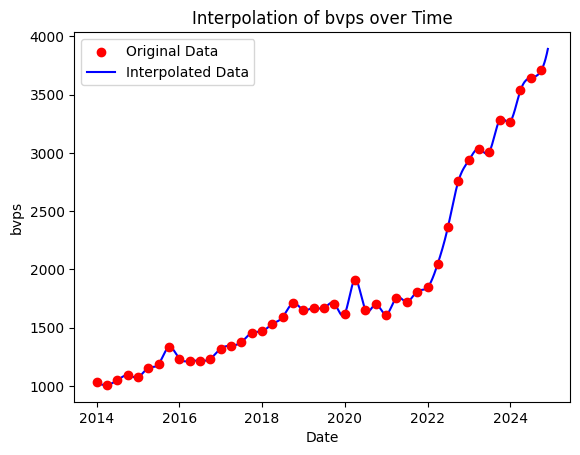

In [52]:
# Select a column to visualize, for example, 'bvps'
column_to_plot = 'bvps'

# Plot original data (with NaN values)
plt.scatter(fun_adro['date'], fun_adro[column_to_plot], color='red', label='Original Data', zorder=5)

# Plot interpolated data
plt.plot(interpolated_fun_adro['Date'], interpolated_fun_adro["interpolated_bvps"], color='blue', label='Interpolated Data', zorder=3)

# Add labels and title
plt.xlabel('Date')
plt.ylabel(column_to_plot)
plt.title(f'Interpolation of {column_to_plot} over Time')

# Add legend
plt.legend()

# Show the plot
plt.show()

In [3]:
df = pd.read_csv('data_harga_adro.csv')
df

,Date,Close,Open,High,Low,Volume,Change
0,2014-01-03 00:00:00+07:00,276.232727,287.172637,289.907615,273.497750,52823000,-0.047170
1,2014-01-06 00:00:00+07:00,254.352936,276.232758,276.232758,247.515491,95833000,-0.079208
2,2014-01-07 00:00:00+07:00,240.677979,254.352864,258.455329,237.943001,161316000,-0.053764
3,2014-01-08 00:00:00+07:00,257.087860,242.045485,257.087860,240.677997,160013700,0.068182
4,2014-01-09 00:00:00+07:00,258.455383,257.087895,265.292827,255.720406,119583300,0.005319
...,...,...,...,...,...,...,...
2693,2024-11-22 00:00:00+07:00,2362.213867,2318.119208,2362.213867,2292.922260,154094300,0.019022
2694,2024-11-25 00:00:00+07:00,2374.812256,2368.513019,2400.009203,2349.615309,192437100,0.005333
2695,2024-11-26 00:00:00+07:00,2311.820068,2381.111678,2406.308627,2311.820068,283961800,-0.026525
2696,2024-11-28 00:00:00+07:00,2760.000000,2760.000000,2760.000000,2760.000000,20071600,0.193865


In [ ]:
interpolated_ = pd.read_csv('interpolated_adro.csv')

In [50]:
price_bbca

,Date,Close,Open,High,Low,Volume,Change,adx,macd,rsi,%k
13,2014-01-23 00:00:00+07:00,1707.868896,1674.381271,1716.240803,1657.637458,160911500,0.030303,100.000000,12.725335,78.148610,94.999998
14,2014-01-24 00:00:00+07:00,1703.682861,1703.682861,1716.240720,1670.195238,90143000,-0.002451,100.000000,14.596453,76.112003,92.499948
15,2014-01-27 00:00:00+07:00,1640.893555,1666.009272,1666.009272,1615.777837,106837500,-0.036855,64.433978,12.024634,53.563327,54.999930
16,2014-01-28 00:00:00+07:00,1674.381592,1640.893960,1682.753500,1632.522052,77513500,0.020408,50.132894,11.986431,60.315951,75.000183
17,2014-01-29 00:00:00+07:00,1674.381592,1682.753500,1732.984948,1674.381592,144919000,0.000000,47.569253,11.810025,60.315951,67.441947
...,...,...,...,...,...,...,...,...,...,...,...
2713,2024-12-20 00:00:00+07:00,9650.000000,9650.000000,9750.000000,9625.000000,91576900,-0.002584,12.129152,-98.328859,37.120280,11.428571
2714,2024-12-23 00:00:00+07:00,9775.000000,9700.000000,9850.000000,9700.000000,43292100,0.012953,12.687622,-105.378451,41.719339,25.714286
2715,2024-12-24 00:00:00+07:00,9750.000000,9850.000000,9900.000000,9750.000000,32415700,-0.002558,12.859850,-111.695043,41.072312,22.857143
2716,2024-12-27 00:00:00+07:00,9800.000000,9800.000000,9825.000000,9725.000000,24016700,0.005128,13.151355,-111.382458,42.977109,28.571429


In [103]:
price_fun_cpin = pd.concat([price_cpin, interpolated_cpin], axis=1)
price_fun_cpin

,Date,Close,Open,High,Low,Volume,Change,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income
0,2014-01-03 00:00:00+07:00,1445.581177,1445.581177,1479.594852,1428.574339,60001000,-0.022989,603.707289,60853.254576,20122.860637,5038.665820,5130.753211,4.692187e+06
1,2014-01-06 00:00:00+07:00,1418.370117,1479.594727,1479.594727,1404.764648,81736300,-0.018824,608.079881,61294.091169,19936.129565,4297.367271,5828.058539,4.735341e+06
2,2014-01-07 00:00:00+07:00,1408.166138,1418.370240,1418.370240,1401.363403,73637100,-0.007194,609.469693,61434.209385,19877.293936,4060.955931,6049.514370,4.749168e+06
3,2014-01-08 00:00:00+07:00,1428.574341,1418.370238,1428.574341,1404.764768,84514500,0.014493,610.826133,61570.963148,19820.140366,3829.819563,6265.553030,4.762721e+06
4,2014-01-09 00:00:00+07:00,1418.370117,1428.574219,1438.778320,1418.370117,71932000,-0.007143,612.149494,61704.381981,19764.655674,3603.916694,6476.217997,4.776003e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2530.000000,2570.000000,2520.000000,110308800,0.007905,1979.828985,196125.587855,-29492.387956,-61685.016277,64209.700488,1.067549e+07
2713,2024-12-23 00:00:00+07:00,2650.000000,2580.000000,2670.000000,2580.000000,72113700,0.039216,2017.891738,199896.168753,-34422.640698,-67125.537011,69679.542197,1.088181e+07
2714,2024-12-24 00:00:00+07:00,2740.000000,2680.000000,2750.000000,2620.000000,117582400,0.033962,2030.862116,201181.043385,-36102.688958,-68979.804256,71544.057442,1.095231e+07
2715,2024-12-27 00:00:00+07:00,2750.000000,2770.000000,2800.000000,2710.000000,92727600,0.003650,2070.631324,205120.670902,-41253.979684,-74666.276543,77262.723749,1.116909e+07


In [104]:
price_fun_cpin['pbv'] = price_fun_cpin['Close'] / price_fun_cpin['interpolated_bvps']
price_fun_cpin

,Date,Close,Open,High,Low,Volume,Change,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income,pbv
0,2014-01-03 00:00:00+07:00,1445.581177,1445.581177,1479.594852,1428.574339,60001000,-0.022989,603.707289,60853.254576,20122.860637,5038.665820,5130.753211,4.692187e+06,2.394507
1,2014-01-06 00:00:00+07:00,1418.370117,1479.594727,1479.594727,1404.764648,81736300,-0.018824,608.079881,61294.091169,19936.129565,4297.367271,5828.058539,4.735341e+06,2.332539
2,2014-01-07 00:00:00+07:00,1408.166138,1418.370240,1418.370240,1401.363403,73637100,-0.007194,609.469693,61434.209385,19877.293936,4060.955931,6049.514370,4.749168e+06,2.310478
3,2014-01-08 00:00:00+07:00,1428.574341,1418.370238,1428.574341,1404.764768,84514500,0.014493,610.826133,61570.963148,19820.140366,3829.819563,6265.553030,4.762721e+06,2.338758
4,2014-01-09 00:00:00+07:00,1418.370117,1428.574219,1438.778320,1418.370117,71932000,-0.007143,612.149494,61704.381981,19764.655674,3603.916694,6476.217997,4.776003e+06,2.317032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2530.000000,2570.000000,2520.000000,110308800,0.007905,1979.828985,196125.587855,-29492.387956,-61685.016277,64209.700488,1.067549e+07,1.287990
2713,2024-12-23 00:00:00+07:00,2650.000000,2580.000000,2670.000000,2580.000000,72113700,0.039216,2017.891738,199896.168753,-34422.640698,-67125.537011,69679.542197,1.088181e+07,1.313252
2714,2024-12-24 00:00:00+07:00,2740.000000,2680.000000,2750.000000,2620.000000,117582400,0.033962,2030.862116,201181.043385,-36102.688958,-68979.804256,71544.057442,1.095231e+07,1.349181
2715,2024-12-27 00:00:00+07:00,2750.000000,2770.000000,2800.000000,2710.000000,92727600,0.003650,2070.631324,205120.670902,-41253.979684,-74666.276543,77262.723749,1.116909e+07,1.328097


In [97]:
price_fun_cpin.to_csv('data/tlkm/data_harga_fundamental_tlkm.csv')

In [ ]:
stock_data['adx'] = TA.ADX(stock_data)
stock_data['macd'] = TA.MACD(stock_data)['MACD']
stock_data['rsi'] = TA.RSI(stock_data)
stock_data['%k'] = TA.STOCH(stock_data)
stock_data

,Date,Close,Open,High,Low,Volume,Change,adx,macd,rsi,%k
0,2014-01-03 00:00:00+07:00,1445.581177,1445.581177,1479.594852,1428.574339,60001000,-0.022989,NaN,0.000000,NaN,NaN
1,2014-01-06 00:00:00+07:00,1418.370117,1479.594727,1479.594727,1404.764648,81736300,-0.018824,NaN,-0.610505,0.000000,NaN
2,2014-01-07 00:00:00+07:00,1408.166138,1418.370240,1418.370240,1401.363403,73637100,-0.007194,NaN,-1.094329,0.000000,NaN
3,2014-01-08 00:00:00+07:00,1428.574341,1418.370238,1428.574341,1404.764768,84514500,0.014493,NaN,-0.550732,38.256349,NaN
4,2014-01-09 00:00:00+07:00,1418.370117,1428.574219,1438.778320,1418.370117,71932000,-0.007143,NaN,-0.649805,31.721730,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2530.000000,2570.000000,2520.000000,110308800,0.007905,19.240769,-48.357637,36.538809,13.157895
2713,2024-12-23 00:00:00+07:00,2650.000000,2580.000000,2670.000000,2580.000000,72113700,0.039216,18.411169,-45.863414,45.452721,39.473684
2714,2024-12-24 00:00:00+07:00,2740.000000,2680.000000,2750.000000,2620.000000,117582400,0.033962,17.476598,-36.207103,51.988966,63.157895
2715,2024-12-27 00:00:00+07:00,2750.000000,2770.000000,2800.000000,2710.000000,92727600,0.003650,17.123477,-27.431280,52.667632,65.789474


In [100]:
price_cpin = price_cpin.dropna()
price_cpin

,Date,Close,Open,High,Low,Volume,Change,adx,macd,rsi,%k
14,2014-01-24 00:00:00+07:00,1503.404541,1503.404541,1520.411380,1489.799070,85992300,-0.006741,100.000000,9.982925,60.176322,73.170818
15,2014-01-27 00:00:00+07:00,1462.587769,1462.587769,1479.594603,1428.574100,79202500,-0.027150,100.000000,6.512098,45.823802,43.902264
16,2014-01-28 00:00:00+07:00,1462.587769,1462.587769,1472.791869,1438.778200,63022000,0.000000,100.000000,3.784294,45.823802,42.499821
17,2014-01-29 00:00:00+07:00,1517.009888,1472.792111,1534.016725,1472.792111,98500700,0.037209,73.724039,5.080087,60.421098,81.578947
18,2014-01-30 00:00:00+07:00,1547.622192,1493.200313,1547.622192,1486.397578,137604700,0.020179,57.744736,7.977870,65.974660,100.000000
...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2530.000000,2570.000000,2520.000000,110308800,0.007905,19.240769,-48.357637,36.538809,13.157895
2713,2024-12-23 00:00:00+07:00,2650.000000,2580.000000,2670.000000,2580.000000,72113700,0.039216,18.411169,-45.863414,45.452721,39.473684
2714,2024-12-24 00:00:00+07:00,2740.000000,2680.000000,2750.000000,2620.000000,117582400,0.033962,17.476598,-36.207103,51.988966,63.157895
2715,2024-12-27 00:00:00+07:00,2750.000000,2770.000000,2800.000000,2710.000000,92727600,0.003650,17.123477,-27.431280,52.667632,65.789474


In [101]:
price_cpin.to_csv('data/tlkm/data_harga_teknikal_tlkm.csv')

In [34]:
price_fun_adro = price_fun_adro.loc[:, ~price_fun_adro.columns.duplicated()]
price_fun_adro

,Date,Close,Open,High,Low,Volume,Change,adx,macd,rsi,%k,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income
0,2014-01-03 00:00:00+07:00,276.232727,287.172637,289.907615,273.497750,52823000,-0.047170,NaN,0.000000,NaN,NaN,1030.198337,32952.008267,27145.336463,18682.189475,7530.696959,7.437152e+08
1,2014-01-06 00:00:00+07:00,254.352921,276.232742,276.232742,247.515476,95833000,-0.079208,NaN,-0.490893,0.000000,NaN,1028.354421,32893.034160,27217.529044,18534.102238,7874.831683,8.455938e+08
2,2014-01-07 00:00:00+07:00,240.678009,254.352896,258.455362,237.943032,161316000,-0.053764,NaN,-1.049553,0.000000,NaN,1027.760586,32874.041595,27238.399122,18485.957407,7983.171007,8.779907e+08
3,2014-01-08 00:00:00+07:00,257.087921,242.045543,257.087921,240.678054,160013700,0.068182,NaN,-0.685448,34.205991,NaN,1027.177091,32855.379766,27257.709272,18438.414408,8088.381402,9.096174e+08
4,2014-01-09 00:00:00+07:00,258.455353,257.087864,265.292796,255.720376,119583300,0.005319,NaN,-0.418754,36.165475,NaN,1026.603899,32837.047475,27275.481775,18391.469068,8190.497187,9.404802e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2540.000000,2580.000000,2510.000000,65183500,0.003937,15.014763,49.571286,53.066851,45.000000,4010.717405,111533.200056,32962.992904,-37039.249669,76526.326710,-3.905191e+09
2713,2024-12-23 00:00:00+07:00,2540.000000,2580.000000,2590.000000,2520.000000,49626700,-0.003922,14.937434,46.610051,52.613183,42.372881,4030.077940,111491.167704,33701.295424,-37616.870198,79026.221391,-4.469444e+09
2714,2024-12-24 00:00:00+07:00,2510.000000,2540.000000,2610.000000,2510.000000,70990000,-0.011811,15.001780,41.365664,51.199076,37.288136,4036.686561,111478.425921,33953.260448,-37812.958562,79878.927204,-4.661340e+09
2715,2024-12-27 00:00:00+07:00,2540.000000,2530.000000,2540.000000,2490.000000,64253200,0.011952,14.861962,39.178572,52.571880,42.372881,4056.984447,111444.116703,34726.960789,-38411.965961,82495.977654,-5.248587e+09


In [105]:
price_fun_cpin['adx'] = TA.ADX(price_cpin)
price_fun_cpin['macd'] = TA.MACD(price_cpin)['MACD']
price_fun_cpin['rsi'] = TA.RSI(price_cpin)
price_fun_cpin['%k'] = TA.STOCH(price_cpin)
price_fun_cpin

,Date,Close,Open,High,Low,Volume,Change,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income,pbv,adx,macd,rsi,%k
0,2014-01-03 00:00:00+07:00,1445.581177,1445.581177,1479.594852,1428.574339,60001000,-0.022989,603.707289,60853.254576,20122.860637,5038.665820,5130.753211,4.692187e+06,2.394507,NaN,0.000000,NaN,NaN
1,2014-01-06 00:00:00+07:00,1418.370117,1479.594727,1479.594727,1404.764648,81736300,-0.018824,608.079881,61294.091169,19936.129565,4297.367271,5828.058539,4.735341e+06,2.332539,NaN,-0.610505,0.000000,NaN
2,2014-01-07 00:00:00+07:00,1408.166138,1418.370240,1418.370240,1401.363403,73637100,-0.007194,609.469693,61434.209385,19877.293936,4060.955931,6049.514370,4.749168e+06,2.310478,NaN,-1.094329,0.000000,NaN
3,2014-01-08 00:00:00+07:00,1428.574341,1418.370238,1428.574341,1404.764768,84514500,0.014493,610.826133,61570.963148,19820.140366,3829.819563,6265.553030,4.762721e+06,2.338758,NaN,-0.550732,38.256349,NaN
4,2014-01-09 00:00:00+07:00,1418.370117,1428.574219,1438.778320,1418.370117,71932000,-0.007143,612.149494,61704.381981,19764.655674,3603.916694,6476.217997,4.776003e+06,2.317032,NaN,-0.649805,31.721730,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,2550.000000,2530.000000,2570.000000,2520.000000,110308800,0.007905,1979.828985,196125.587855,-29492.387956,-61685.016277,64209.700488,1.067549e+07,1.287990,19.240769,-48.357637,36.538809,13.157895
2713,2024-12-23 00:00:00+07:00,2650.000000,2580.000000,2670.000000,2580.000000,72113700,0.039216,2017.891738,199896.168753,-34422.640698,-67125.537011,69679.542197,1.088181e+07,1.313252,18.411169,-45.863414,45.452721,39.473684
2714,2024-12-24 00:00:00+07:00,2740.000000,2680.000000,2750.000000,2620.000000,117582400,0.033962,2030.862116,201181.043385,-36102.688958,-68979.804256,71544.057442,1.095231e+07,1.349181,17.476598,-36.207103,51.988966,63.157895
2715,2024-12-27 00:00:00+07:00,2750.000000,2770.000000,2800.000000,2710.000000,92727600,0.003650,2070.631324,205120.670902,-41253.979684,-74666.276543,77262.723749,1.116909e+07,1.328097,17.123477,-27.431280,52.667632,65.789474


In [83]:
price_fun_cpin['pbv'] = price_fun_cpin['Close'] / price_fun_cpin['interpolated_bvps']
price_fun_cpin

,Date,Close,Open,High,Low,Volume,Change,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income,adx,macd,rsi,%k,pbv
0,2014-01-03 00:00:00+07:00,2899.854248,2942.499163,3006.466537,2899.854248,7189500,-0.035461,608.180203,9972.734639,3123.092310,1995.968840,6534.425221,338671.820268,NaN,0.000000,NaN,NaN,4.768084
1,2014-01-06 00:00:00+07:00,2882.796875,2878.532383,2933.970784,2861.474413,5757600,-0.005882,611.640951,10029.551999,3095.424565,1996.893409,6585.189191,362670.409530,NaN,-0.382697,0.000000,NaN,4.713218
2,2014-01-07 00:00:00+07:00,2814.564697,2882.796569,2882.796569,2814.564697,5678800,-0.023669,612.750065,10047.760831,3086.780096,1997.458602,6601.096639,370416.000777,NaN,-2.603508,0.000000,NaN,4.593332
3,2014-01-08 00:00:00+07:00,2878.532227,2814.564844,2891.325703,2780.448906,3621500,0.022727,613.837257,10065.609633,3078.421809,1998.151458,6616.505129,378036.108519,NaN,-1.240248,45.036895,NaN,4.689406
4,2014-01-09 00:00:00+07:00,2938.235107,2835.887295,2942.499600,2835.887295,6190900,0.020741,614.902712,10083.101471,3070.347981,1998.971475,6631.419451,385531.624207,NaN,1.902353,62.164274,NaN,4.778374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,4660.000000,4620.000000,4720.000000,4620.000000,21419300,0.013043,1886.026281,30929.708169,16866.061276,11863.929396,13349.885851,800667.321071,21.987233,-30.791688,39.710064,10.000000,2.470803
2713,2024-12-23 00:00:00+07:00,4850.000000,4700.000000,4910.000000,4700.000000,3153300,0.040773,1893.268529,31048.663186,17358.816896,12280.687671,13491.939856,832258.636840,21.356015,-24.265238,51.026739,41.666667,2.561707
2714,2024-12-24 00:00:00+07:00,4730.000000,4850.000000,4860.000000,4730.000000,2106200,-0.024742,1895.733418,31089.149619,17527.025651,12423.367633,13540.103134,843298.959625,20.769883,-28.448045,45.249738,21.666667,2.495077
2715,2024-12-27 00:00:00+07:00,4760.000000,4740.000000,4830.000000,4740.000000,1903900,0.006342,1903.282524,31213.146377,18043.665683,12862.832184,13687.059912,877977.632522,20.225619,-29.007816,46.869218,26.666667,2.500942


In [106]:
price_fun_cpin = price_fun_cpin.dropna()
price_fun_cpin.to_csv('data/tlkm/data_kombinasi_tlkm.csv')

In [108]:
test = pd.read_csv('data/cpin/data_kombinasi_cpin.csv')
test

,Unnamed: 0,Date,Close,Open,High,Low,Volume,Change,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income,adx,macd,rsi,%k,pbv
0,0,2014-01-03 00:00:00+07:00,2899.854248,2942.499163,3006.466537,2899.854248,7189500,-0.035461,608.180203,9972.734639,3123.092310,1995.968840,6534.425221,338671.820268,NaN,0.000000,NaN,NaN,4.768084
1,1,2014-01-06 00:00:00+07:00,2882.796875,2878.532383,2933.970784,2861.474413,5757600,-0.005882,611.640951,10029.551999,3095.424565,1996.893409,6585.189191,362670.409530,NaN,-0.382697,0.000000,NaN,4.713218
2,2,2014-01-07 00:00:00+07:00,2814.564697,2882.796569,2882.796569,2814.564697,5678800,-0.023669,612.750065,10047.760831,3086.780096,1997.458602,6601.096639,370416.000777,NaN,-2.603508,0.000000,NaN,4.593332
3,3,2014-01-08 00:00:00+07:00,2878.532227,2814.564844,2891.325703,2780.448906,3621500,0.022727,613.837257,10065.609633,3078.421809,1998.151458,6616.505129,378036.108519,NaN,-1.240248,45.036895,NaN,4.689406
4,4,2014-01-09 00:00:00+07:00,2938.235107,2835.887295,2942.499600,2835.887295,6190900,0.020741,614.902712,10083.101471,3070.347981,1998.971475,6631.419451,385531.624207,NaN,1.902353,62.164274,NaN,4.778374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2712,2024-12-20 00:00:00+07:00,4660.000000,4620.000000,4720.000000,4620.000000,21419300,0.013043,1886.026281,30929.708169,16866.061276,11863.929396,13349.885851,800667.321071,21.987233,-30.791688,39.710064,10.000000,2.470803
2713,2713,2024-12-23 00:00:00+07:00,4850.000000,4700.000000,4910.000000,4700.000000,3153300,0.040773,1893.268529,31048.663186,17358.816896,12280.687671,13491.939856,832258.636840,21.356015,-24.265238,51.026739,41.666667,2.561707
2714,2714,2024-12-24 00:00:00+07:00,4730.000000,4850.000000,4860.000000,4730.000000,2106200,-0.024742,1895.733418,31089.149619,17527.025651,12423.367633,13540.103134,843298.959625,20.769883,-28.448045,45.249738,21.666667,2.495077
2715,2715,2024-12-27 00:00:00+07:00,4760.000000,4740.000000,4830.000000,4740.000000,1903900,0.006342,1903.282524,31213.146377,18043.665683,12862.832184,13687.059912,877977.632522,20.225619,-29.007816,46.869218,26.666667,2.500942


In [109]:
test = test.drop(columns=['Unnamed: 0'])
test = test.dropna()
test

,Date,Close,Open,High,Low,Volume,Change,interpolated_bvps,interpolated_equity,interpolated_total_debt,interpolated_net_debt,interpolated_working_capital,interpolated_net_income,adx,macd,rsi,%k,pbv
13,2014-01-23 00:00:00+07:00,3360.419922,3462.767737,3479.825706,3360.419922,6886100,-0.022332,627.641408,10292.224044,2986.216834,2023.521774,6791.013769,477885.889616,100.000000,58.422362,75.717821,82.926831,5.354044
14,2014-01-24 00:00:00+07:00,3313.510742,3313.510742,3377.478131,3283.659294,9489900,-0.013959,628.403237,10304.729571,2982.202953,2026.188818,6799.090173,483619.498388,67.307941,54.240114,69.192059,76.219548,5.272905
15,2014-01-27 00:00:00+07:00,3292.187988,3270.865527,3360.419864,3044.847440,15219800,-0.006435,630.576988,10340.411157,2971.695620,2034.902601,6820.833218,500161.917298,71.428996,49.091693,66.391061,73.170726,5.220914
16,2014-01-28 00:00:00+07:00,3411.593262,3292.187498,3441.444703,3283.658514,14279100,0.036269,631.264949,10351.703579,2968.698865,2038.043068,6827.268139,505459.559299,64.149206,51.945423,72.985995,90.243822,5.404376
17,2014-01-29 00:00:00+07:00,3475.561035,3441.445099,3603.495797,3441.445099,21611900,0.018750,631.934909,10362.700394,2965.952080,2041.300633,6833.304660,510650.438229,50.449851,57.526384,75.733197,83.333332,5.499872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,2024-12-20 00:00:00+07:00,4660.000000,4620.000000,4720.000000,4620.000000,21419300,0.013043,1886.026281,30929.708169,16866.061276,11863.929396,13349.885851,800667.321071,21.987233,-30.791688,39.710064,10.000000,2.470803
2713,2024-12-23 00:00:00+07:00,4850.000000,4700.000000,4910.000000,4700.000000,3153300,0.040773,1893.268529,31048.663186,17358.816896,12280.687671,13491.939856,832258.636840,21.356015,-24.265238,51.026739,41.666667,2.561707
2714,2024-12-24 00:00:00+07:00,4730.000000,4850.000000,4860.000000,4730.000000,2106200,-0.024742,1895.733418,31089.149619,17527.025651,12423.367633,13540.103134,843298.959625,20.769883,-28.448045,45.249738,21.666667,2.495077
2715,2024-12-27 00:00:00+07:00,4760.000000,4740.000000,4830.000000,4740.000000,1903900,0.006342,1903.282524,31213.146377,18043.665683,12862.832184,13687.059912,877977.632522,20.225619,-29.007816,46.869218,26.666667,2.500942


In [110]:
test.to_csv('data/cpin/data_kombinasi_cpin.csv')

In [7]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

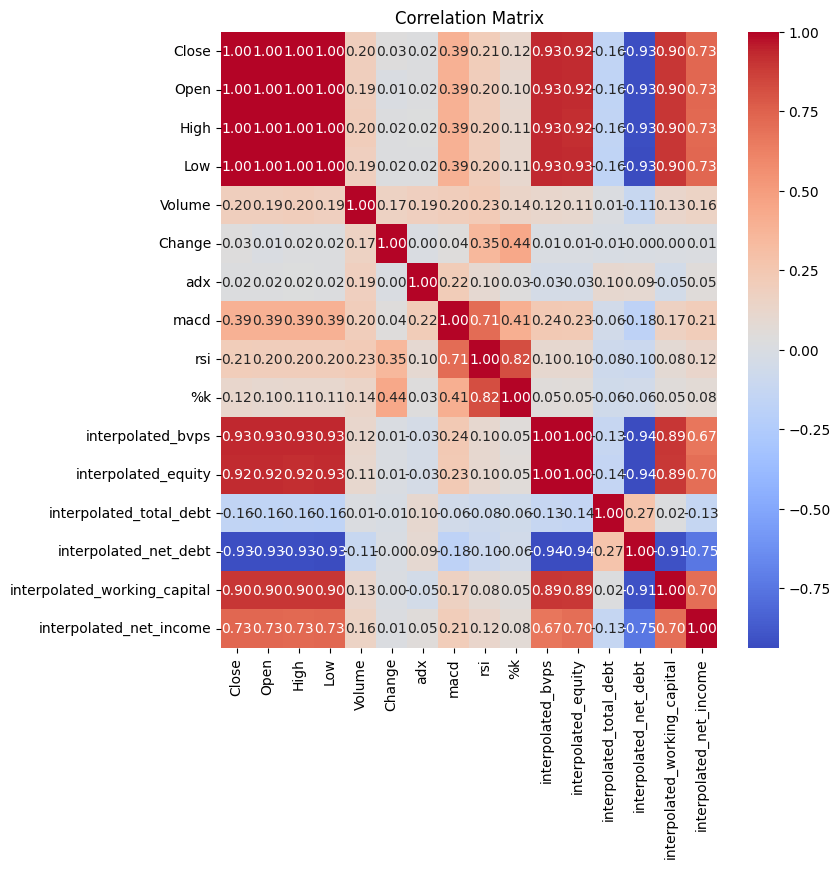

In [8]:
corr_matrix = df.corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show